In [1]:
!pip -q install opencv-python numpy matplotlib pandas tqdm

In [2]:
import os, json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
ROI_OUT_DIR = "/content/drive/MyDrive/Mirror Vision-KARIGOR/MirrorVision_ROI_Output_IF"
CROPS_DIR = os.path.join(ROI_OUT_DIR, "crops")

print("CROPS_DIR exists?", os.path.exists(CROPS_DIR))

CROPS_DIR exists? True


Helper: show image

In [6]:
def show(img_bgr, title="", figsize=(4,4)):
    if img_bgr is None:
        print("None image:", title)
        return
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

Load ROI crop paths per image

In [7]:
def list_image_folders(crops_dir):
    return sorted([
        os.path.join(crops_dir, d)
        for d in os.listdir(crops_dir)
        if os.path.isdir(os.path.join(crops_dir, d))
    ])

img_folders = list_image_folders(CROPS_DIR)
print("Total ROI image folders:", len(img_folders))
print("Sample folder:", img_folders[:1])

Total ROI image folders: 44
Sample folder: ['/content/drive/MyDrive/Mirror Vision-KARIGOR/MirrorVision_ROI_Output_IF/crops/IMG-20260112-WA0000']


Score 1: Dark circle score (Under-eye)

Logic:

under-eye ROI grayscale average darker হলে score বেশি

normalize: 0–100

In [8]:
def dark_circle_score(roi_bgr):
    if roi_bgr is None or roi_bgr.size == 0:
        return None
    # convert to LAB to handle illumination a bit better
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L = lab[:,:,0].astype(np.float32)  # 0-255
    # darker = lower L
    mean_L = float(np.mean(L))
    # map: lower L -> higher score
    # clamp to a reasonable range
    score = (120.0 - mean_L) * (100.0/80.0)  # heuristic scale
    score = max(0.0, min(100.0, score))
    return score

Score 2: Wrinkle texture score (Forehead)

Logic:

high-frequency texture energy বেশি হলে wrinkle/lines possibility বেশি

Laplacian variance + edge density combine

In [9]:
def wrinkle_texture_score(roi_bgr):
    if roi_bgr is None or roi_bgr.size == 0:
        return None
    g = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)

    # high frequency measure
    lap_var = float(cv2.Laplacian(g, cv2.CV_64F).var())

    # edge density
    edges = cv2.Canny(g, 60, 120)
    edge_density = float((edges > 0).mean())  # 0-1

    # combine to 0-100 (heuristic)
    # lap_var typical ranges widely; compress with log
    lap_term = np.log1p(lap_var) * 12.0  # scale
    edge_term = edge_density * 120.0

    raw = lap_term + edge_term
    score = max(0.0, min(100.0, raw))
    return score

Score 3: Acne/spot count (Cheek ROI) — Simple blob detector

Logic:

convert to gray

enhance contrast

detect small dark/red spots via adaptive threshold + contour filtering

In [10]:
def acne_spot_count(roi_bgr):
    if roi_bgr is None or roi_bgr.size == 0:
        return None, None

    img = roi_bgr.copy()
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # contrast normalize (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g2 = clahe.apply(g)

    # detect darker micro-regions
    th = cv2.adaptiveThreshold(g2, 255,
                              cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                              cv2.THRESH_BINARY_INV,
                              31, 5)

    # clean
    kernel = np.ones((3,3), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)

    # contours
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    spots = 0
    vis = img.copy()

    h, w = g.shape[:2]
    area_min = 0.00008 * (h*w)   # small
    area_max = 0.01 * (h*w)      # not too large

    for c in cnts:
        a = cv2.contourArea(c)
        if a < area_min or a > area_max:
            continue

        x,y,ww,hh = cv2.boundingRect(c)

        # simple shape filter
        if ww < 3 or hh < 3:
            continue

        spots += 1
        cv2.rectangle(vis, (x,y), (x+ww,y+hh), (0,255,255), 1)

    return spots, vis

Extract scores for each image folder

এখানে আমরা left/right under-eye average নেব, left/right cheek sum করবো।

In [11]:
def read_crop(folder, name):
    p = os.path.join(folder, f"{name}.jpg")
    if not os.path.exists(p):
        return None
    img = cv2.imread(p)
    return img

rows = []
sample_debug = []

for fld in tqdm(img_folders):
    base = os.path.basename(fld)

    forehead = read_crop(fld, "forehead")
    lue = read_crop(fld, "left_undereye")
    rue = read_crop(fld, "right_undereye")
    lch = read_crop(fld, "left_cheek")
    rch = read_crop(fld, "right_cheek")
    lips = read_crop(fld, "lips")

    # Scores
    dc_l = dark_circle_score(lue)
    dc_r = dark_circle_score(rue)
    dark_circle = None
    if dc_l is not None and dc_r is not None:
        dark_circle = float((dc_l + dc_r)/2.0)
    elif dc_l is not None:
        dark_circle = float(dc_l)
    elif dc_r is not None:
        dark_circle = float(dc_r)

    wrinkle = wrinkle_texture_score(forehead)

    acne_l, vis_l = acne_spot_count(lch)
    acne_r, vis_r = acne_spot_count(rch)
    acne_total = None
    if acne_l is not None and acne_r is not None:
        acne_total = int(acne_l + acne_r)
    elif acne_l is not None:
        acne_total = int(acne_l)
    elif acne_r is not None:
        acne_total = int(acne_r)

    rows.append({
        "image_id": base,
        "dark_circle_score": dark_circle,
        "wrinkle_texture_score": wrinkle,
        "acne_spot_count": acne_total
    })

    # collect some debug samples
    if len(sample_debug) < 3 and vis_l is not None:
        sample_debug.append((base, lch, vis_l))

df = pd.DataFrame(rows)
df.head()

100%|██████████| 44/44 [01:51<00:00,  2.54s/it]


,image_id,dark_circle_score,wrinkle_texture_score,acne_spot_count
0,IMG-20260112-WA0000,1.573339,56.522048,200
1,IMG-20260112-WA0001,3.103890,79.265282,211
2,IMG-20260112-WA0002,8.830323,88.438486,224
3,IMG-20260112-WA0003,0.000000,71.581741,321
4,IMG-20260112-WA0004,0.574021,37.625032,203


Summary stats + Save CSV

In [12]:
print(df.describe(include="all"))

csv_path = os.path.join(ROI_OUT_DIR, "skin_scores_v1.csv")
df.to_csv(csv_path, index=False)
print("Saved:", csv_path)

                   image_id  dark_circle_score  wrinkle_texture_score  \
count                    44          44.000000              44.000000   
unique                   44                NaN                    NaN   
top     IMG-20260112-WA0000                NaN                    NaN   
freq                      1                NaN                    NaN   
mean                    NaN           8.199286              63.814353   
std                     NaN          16.005479              16.725149   
min                     NaN           0.000000              30.935405   
25%                     NaN           0.000000              48.184504   
50%                     NaN           0.000000              68.143423   
75%                     NaN           8.078167              77.388758   
max                     NaN          69.671040              88.438486   

        acne_spot_count  
count         44.000000  
unique              NaN  
top                 NaN  
freq               

Show top cases (Demo-friendly)

Highest dark circle

In [13]:
top_dc = df.dropna(subset=["dark_circle_score"]).sort_values("dark_circle_score", ascending=False).head(5)
top_dc

,image_id,dark_circle_score,wrinkle_texture_score,acne_spot_count
32,IMG_20260114_144528_893,69.671040,74.509235,879
23,IMG_20260113_154149_293,64.304442,52.938637,688
29,IMG_20260114_144452_295,36.704788,67.215983,1426
30,IMG_20260114_144510_964,34.835124,63.258355,1242
31,IMG_20260114_144519_939,30.112643,60.992665,1136


Highest wrinkle texture

In [14]:
top_wr = df.dropna(subset=["wrinkle_texture_score"]).sort_values("wrinkle_texture_score", ascending=False).head(5)
top_wr

,image_id,dark_circle_score,wrinkle_texture_score,acne_spot_count
2,IMG-20260112-WA0002,8.830323,88.438486,224
21,IMG_20260113_154130_810,0.000000,88.265843,1333
8,IMG-20260112-WA0008,0.000000,87.148541,298
17,IMG_20260112_205702_579,0.000000,85.303805,1209
18,IMG_20260112_205709_227,0.000000,82.719776,1051


Highest acne count

In [15]:
top_ac = df.dropna(subset=["acne_spot_count"]).sort_values("acne_spot_count", ascending=False).head(5)
top_ac

,image_id,dark_circle_score,wrinkle_texture_score,acne_spot_count
19,IMG_20260113_154058_610,0.000000,76.977042,1503
28,IMG_20260114_144432_984,0.000000,71.369160,1486
25,IMG_20260113_154207_023,0.000000,77.404021,1443
26,IMG_20260113_154217_302,0.000000,77.125626,1429
29,IMG_20260114_144452_295,36.704788,67.215983,1426


Debug visualization (Acne detector overlay)

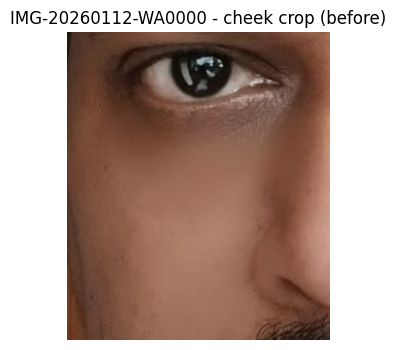

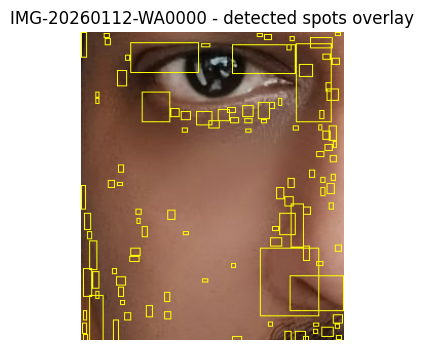

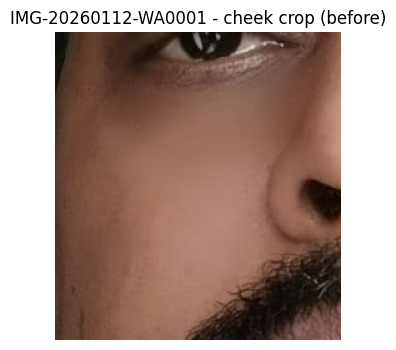

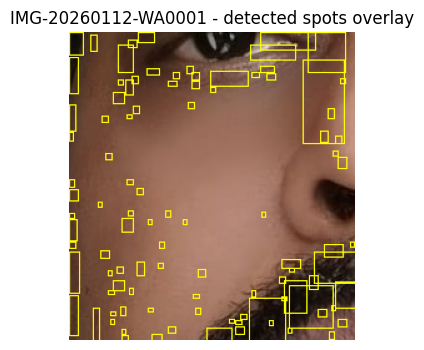

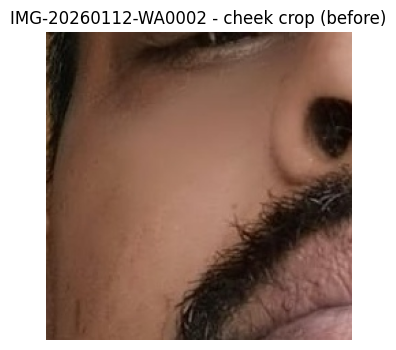

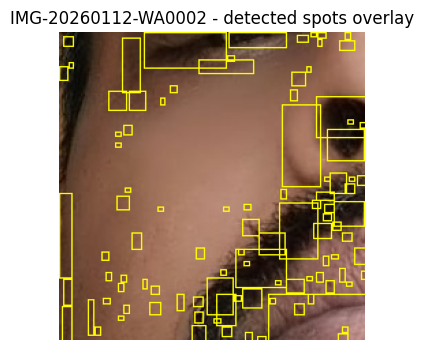

In [16]:
for base, before, after in sample_debug:
    show(before, f"{base} - cheek crop (before)", figsize=(4,4))
    show(after,  f"{base} - detected spots overlay", figsize=(4,4))